In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# --!--------------------------------------------------------------------------
# --! prepare a dataset

# --! define known data properties
timeseries_len  = 101
timestep        = 0.001
dataset_dir     = 'cavity/10Hz_short_ts'

# --! read data from files
data_train = utils.read_datafile(f'{dataset_dir}/train1', timeseries_len)
data_valid = utils.read_datafile(f'{dataset_dir}/valid', timeseries_len)
data_test = utils.read_datafile(f'{dataset_dir}/test', timeseries_len)

# --! data channels are expected to contain:
# --! 1. displacement
# --! 2. velocity
# --! 3. rf field gradient squared
x_dims_n = 2
u_dims_n  = 1

# --! compile dataset parameters
data_table = [
    ( 'dataset',           'batches',        'timeseries length',          'channels'),
    ('--------',           '-------',        '-----------------',          '--------'),
    (   'train', data_train.shape[0], data_train.shape[1], data_train.shape[2]),
    (   'valid', data_valid.shape[0], data_valid.shape[1], data_valid.shape[2]),
    (    'test',  data_test.shape[0],  data_test.shape[1],  data_test.shape[2]) ]

# --! print dataset parameters
print('inf >> dataset parameters:')
print('')
for row in data_table:
    print(f'{row[0]:>8} {row[1]:>8} {row[2]:>18} {row[3]:>8}')

inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                101        3
   valid     1000                101        3
    test      500                101        3


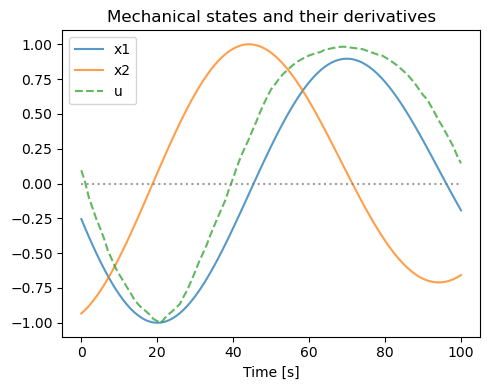

In [3]:
data_i = 123
data_viz = data_train[data_i]
t_viz = torch.linspace(0., timestep*timeseries_len, timeseries_len)
zero_viz = torch.zeros_like(t_viz)

plt.figure(figsize=(5, 4))
plt.title('Mechanical states and their derivatives')
plt.plot(data_viz[:, 0], color='tab:blue', alpha=0.75, label='x1')
plt.plot(data_viz[:, 1], color='tab:orange', alpha=0.75, label='x2')
plt.plot(data_viz[:, 2], color='tab:green', linestyle='dashed', alpha=0.75, label='u')
plt.plot(zero_viz, color='tab:gray', linestyle='dotted', alpha=0.75)
plt.legend()
plt.xlabel('Time [s]')
plt.tight_layout()
plt.show()

In [4]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

model = care.detune()

/Users/maalberg/miniforge3/envs/care/lib/python3.13/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


inf >> Number of data files for training : 4
inf >> Processing training file number 1
inf >> Processing training file number 2
inf >> Processing training file number 3
inf >> Processing training file number 4


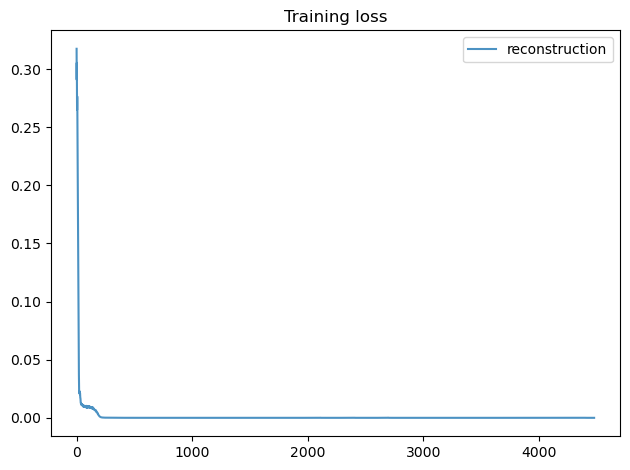

In [5]:
# --!--------------------------------------------------------------------------
# --! training and validation

bat_sz = 128

# --! make validation datasets and loaders
dataset_valid = torch.utils.data.TensorDataset(data_valid)
dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=bat_sz, shuffle=False)

# --! specify optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-8)

# --! empty arrays to gather statistics
loss_train_recon = []
loss_train_phys  = []

# --! training duration
datafiles_train_n = 4
epochs_n          = 40
print(f"inf >> Number of data files for training : {datafiles_train_n}")

for datafile_train in range(datafiles_train_n):
    print(f"inf >> Processing training file number {datafile_train + 1}")

    # --! make training datasets and loaders
    data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=bat_sz, shuffle=True)

    # --! train
    for epoch in range(epochs_n):

        # --! train neural networks
        for this, data in enumerate(dataloader_train):
            x  = data[0][:, :100, :1] # take only displacement
            u  = data[0][:, :100, x_dims_n:]

            optimizer.zero_grad()

            # --! fit a model to training data
            loss = model.fit(x)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                loss_train_recon.append(loss)

# --! display training statistics
with torch.no_grad():
    plt.figure()
    plt.title('Training loss')
    plt.plot(loss_train_recon, alpha=0.8, label='reconstruction')
    plt.legend()
    plt.tight_layout()
    plt.show()

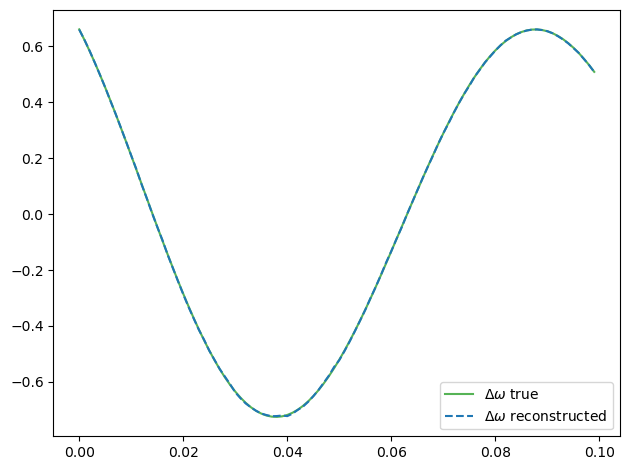

In [6]:
with torch.no_grad():
    data_i  = 44
    data    = data_test[data_i]

    timeseries = torch.unsqueeze(data[:100, :1], dim=0)
    timeseries_recon = model(timeseries)

    #fun_params = torch.cat([o[0] for o in outs], dim=2)
    #fun_params = torch.squeeze(fun_params, (0, 1))

    # --! extract measurement functions from an output list of tuples
    #funs = torch.cat([o[1] for o in outs], dim=1)
    #funs = torch.squeeze(funs, dim=0)

    # --! extract reconstructed timeseries from an output list of tuples
    #timeseries_recon = torch.cat([o[2] for o in outs], dim=-1)

    timeseries = torch.squeeze(timeseries, dim=0)
    timeseries_recon = torch.squeeze(timeseries_recon, dim=0)

    t = np.arange(0., 100*timestep, timestep)

    plt.figure()
    plt.plot(t, timeseries[:, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
    plt.plot(t, timeseries_recon[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ reconstructed')
    plt.legend()
    plt.tight_layout()
    plt.show()

    #plt.figure()
    #plt.plot(fun_params[:, 0], label='sin amp')
    #plt.plot(fun_params[:, 1], label='sin freq')
    #plt.plot(fun_params[:, 2], label='cos amp')
    #plt.plot(fun_params[:, 3], label='cos freq')
    #plt.legend()
    #plt.tight_layout()
    #plt.show()

    #plt.figure()
    #plt.plot(funs[:, 0], label='sin')
    #plt.plot(funs[:, 1], label='cos')
    #plt.plot(funs[:, 2], label='exp')
    #plt.legend()
    #plt.tight_layout()
    #plt.show()